In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import re
import jieba

In [2]:
# Load CSVs
df_en = pd.read_csv('imdb_reviews.csv')

# Download English stopwords if needed
nltk.download('stopwords')
eng_stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/elimarx/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt_tab')
def improved_clean_text(text):
    # First, handle sentence boundaries properly
    sentences = sent_tokenize(str(text))
    
    processed_sentences = []
    for sentence in sentences:
        # Convert to lowercase
        sentence = sentence.lower()
        
        # Keep periods and some punctuation for sentence structure
        sentence = re.sub(r'[^\w\s\.\!\?]', ' ', sentence)
        
        # Remove extra whitespace but preserve sentence boundaries
        sentence = re.sub(r'\s+', ' ', sentence).strip()
        
        if len(sentence) > 10:  # Filter very short sentences
            processed_sentences.append(sentence)
    
    # Join sentences with proper spacing
    clean_text = ' '.join(processed_sentences)
    
    # Remove stop words but keep sentence structure
    stop_words = set(stopwords.words('english'))
    # Don't remove movie-specific terms that might be meaningful
    movie_stopwords = {'movie', 'film'} # Keep these, they might be important for context
    stop_words = stop_words - movie_stopwords
    
    words = word_tokenize(clean_text)
    filtered_words = [w for w in words if w.lower() not in stop_words or w in '.!?']
    
    return ' '.join(filtered_words)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/elimarx/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
df_en.loc[0]['comment']

"So when this movie came out, it was pretty gory and disgusting however, with today's society in the shows that have been on television like law and order SVU anything along the lines of fun of a CSI type event it's pretty much made these movies not so bad to wear when I first watched it I was just horrified how disgusted it was. Watching this now, I'd probably give it a five or six still good movie like the ending of course but not really sure on giving it anything more than that. I will say Morgan Freeman's character was very good and Brad Pitt was good as well. Just hard to get past to discuss this which led me to leave the theater actually during this movie."

In [5]:
df_en.loc[0]['clean_comment']

KeyError: 'clean_comment'

In [26]:
# Apply preprocessing
df_en['clean_comment'] = df_en['comment'].apply(improved_clean_text)
comments = df_en["clean_comment"].dropna().tolist()

In [17]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")

embeddings = model.encode(comments, show_progress_bar=True)

/Users/elimarx/miniconda3/lib/python3.13/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
/Users/elimarx/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/Users/elimarx/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/Users/elimarx/miniconda3/lib/python3.13/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0

In [18]:
#do clustering
from sklearn.cluster import KMeans

num_clusters = 6  # tweak this
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

df_en['cluster'] = labels

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [19]:
#print some random comments from each cluster
for cluster_num in sorted(df_en['cluster'].unique()):
    print(f"\nCluster {cluster_num}:")
    sample_comments = df_en[df_en['cluster'] == cluster_num]['clean_comment'].sample(4, random_state=42)
    for comment in sample_comments:
        print(" -", comment)


Cluster 0:
 - guy mental issues like job friends family unhappy sleep ... doctor advises join therapy session people cancer people die soon . . go see real pain . . looks like sentence monk sold ferrari type philosopher sentence medical doctor . . unnamed guy goes sees much unhappy people likes like marla singer . . marla anything fun . . disease . . another completely lost character . . two anti heros lead roles makes film unique . . movie symbolizes beginning new era . . always seen hero anti hero hollywood productions including fincher previous movies . . edward norton never stops narrating always sounds tone hear single emotional change . . plane meets tyler durden shows another way solve problems . . bar visit fight like . . build fight club many anti heros join . . begin go beyond borders killing people destroying capitalist buildings think devils . . kicking breaking noses bones blowing banks making stupid prunks foreign people bring peace world . . movie really glorifies viole

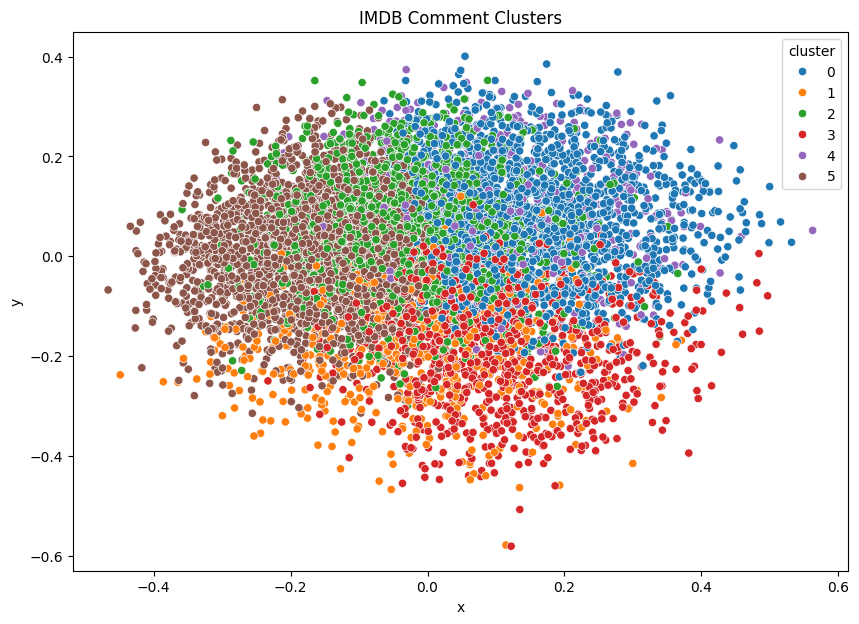

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

df_en['x'] = reduced[:, 0]
df_en['y'] = reduced[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_en, x='x', y='y', hue='cluster', palette='tab10')
plt.title("IMDB Comment Clusters")
plt.show()

In [24]:
from keybert import KeyBERT

kw_model = KeyBERT(model)
for i in range(num_clusters):
    cluster_comments = df_en[df_en['cluster'] == i]['clean_comment'].tolist()
    joined = " ".join(cluster_comments)
    keywords = kw_model.extract_keywords(joined, top_n=5, diversity=0.2)
    print(f"Cluster {i} keywords:", keywords)

Cluster 0 keywords: [('screenplays', 0.5627), ('screenplay', 0.5328), ('cinematograpthy', 0.5292), ('cinematopography', 0.5096), ('hollywoodisms', 0.4978)]
Cluster 1 keywords: [('movie', 0.4655), ('tangled', 0.4325), ('inception', 0.4264), ('cinema', 0.4182), ('moana', 0.4157)]
Cluster 2 keywords: [('uninterestedstellar', 0.4664), ('screenplay', 0.4281), ('interstellar', 0.4173), ('sicario', 0.3977), ('alien3', 0.3927)]
Cluster 3 keywords: [('biopics', 0.4), ('biopic', 0.3934), ('murders', 0.3915), ('screenplay', 0.3839), ('tarantino', 0.3829)]
Cluster 4 keywords: [('hollywoodization', 0.4786), ('screenplay', 0.4468), ('spielberg', 0.4366), ('cinematogophry', 0.4359), ('films', 0.4307)]
Cluster 5 keywords: [('screenplay', 0.4696), ('worstfilm', 0.4522), ('movie', 0.4417), ('brokeback', 0.425), ('cinema', 0.4018)]


In [23]:
from keybert import KeyBERT

# Use better parameters for KeyBERT
kw_model = KeyBERT(model)

for i in range(num_clusters):
    cluster_comments = df_en[df_en['cluster'] == i]['clean_comment'].tolist()
    joined = " ".join(cluster_comments)
    
    # Better KeyBERT parameters
    keywords = kw_model.extract_keywords(
        joined, 
        keyphrase_ngram_range=(1, 1),  # Allow 1-3 word phrases
        stop_words='english',          # Use built-in stop words
        top_n=1,                      # Get more keywords
        use_mmr=True,                  # Use Maximum Marginal Relevance for diversity
        diversity=0.5                  # Balance between relevance and diversity
    )
    
    print(f"Cluster {i} keywords:", keywords)


Cluster 0 keywords: [('screenplays', 0.5627)]
Cluster 1 keywords: [('movie', 0.4655)]
Cluster 2 keywords: [('uninterestedstellar', 0.4664)]
Cluster 3 keywords: [('biopics', 0.4)]
Cluster 4 keywords: [('hollywoodization', 0.4786)]
Cluster 5 keywords: [('screenplay', 0.4696)]


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def get_cluster_keywords_tfidf(df, cluster_col='cluster', text_col='clean_comment'):
    """Get meaningful keywords using TF-IDF"""
    
    # Create documents for each cluster
    cluster_docs = []
    cluster_ids = []
    
    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_text = ' '.join(df[df[cluster_col] == cluster_id][text_col].tolist())
        cluster_docs.append(cluster_text)
        cluster_ids.append(cluster_id)
    
    # Use TF-IDF with better parameters
    tfidf = TfidfVectorizer(
        max_features=1000,
        ngram_range=(1, 3),
        stop_words='english',
        min_df=2,  # Word must appear in at least 2 documents
        max_df=0.8  # Ignore words that appear in >80% of documents
    )
    
    tfidf_matrix = tfidf.fit_transform(cluster_docs)
    feature_names = tfidf.get_feature_names_out()
    
    # Get top words for each cluster
    for i, cluster_id in enumerate(cluster_ids):
        tfidf_scores = tfidf_matrix[i].toarray()[0]
        top_indices = tfidf_scores.argsort()[-10:][::-1]
        top_words = [(feature_names[idx], tfidf_scores[idx]) for idx in top_indices]
        
        print(f"Cluster {cluster_id} TF-IDF keywords:")
        for word, score in top_words:
            print(f"  {word}: {score:.3f}")
        print()

# Use it
get_cluster_keywords_tfidf(df_en)

Cluster 0 TF-IDF keywords:
  swan: 0.248
  benjamin: 0.206
  fincher: 0.180
  nash: 0.163
  portman: 0.161
  ballet: 0.154
  nina: 0.151
  black swan: 0.147
  gosling: 0.147
  benjamin button: 0.121

Cluster 1 TF-IDF keywords:
  anna: 0.573
  toy story: 0.319
  riley: 0.274
  carl: 0.214
  snowman: 0.160
  potter: 0.156
  disney movie: 0.143
  harry potter: 0.139
  disney pixar: 0.136
  robots: 0.136

Cluster 2 TF-IDF keywords:
  matrix: 0.368
  interstellar: 0.308
  bourne: 0.306
  martian: 0.247
  nasa: 0.202
  ledger: 0.163
  knight: 0.148
  dark knight: 0.139
  2001 space: 0.137
  christopher nolan: 0.133

Cluster 3 TF-IDF keywords:
  freddie: 0.656
  mercury: 0.318
  malek: 0.187
  freddie mercury: 0.182
  48: 0.165
  rami: 0.136
  gotham: 0.136
  ledger: 0.131
  matrix: 0.131
  mc: 0.130

Cluster 4 TF-IDF keywords:
  jews: 0.368
  schindler: 0.339
  nazis: 0.310
  germans: 0.247
  wwii: 0.214
  basterds: 0.210
  schindler list: 0.200
  war movie: 0.176
  hitler: 0.169
  concentra